In [1]:
import condor
import tqdm
import numpy as np

import scipy.fft as fft
import scipy.constants as constants

from skimage.measure import block_reduce

import matplotlib.pyplot as plt
from helper_functions import (write_text, radial, electron_density_to_dn, add_water_saxs)

import h5py

# Elementary constants
pi = constants.pi
e = constants.elementary_charge
h = constants.Planck
c = constants.speed_of_light

In [2]:
# Loading normal AGIPD detector mask and crop it around beam center
bg_mask = 'emc/make_detector/agipd_detector_mask.h5'
with h5py.File(bg_mask, 'r') as det:
    det_mask = det['mask'][:]
write_text(f'Shape of detector file: {det_mask.shape}\n')
write_text('Cropping AGIPD detector to square array!\n')
cy, cx = det_mask.shape[0] // 2, det_mask.shape[1] // 2
det_mask = det_mask[cy-cx:cy+cx]
cy, cx = det_mask.shape[0] // 2, det_mask.shape[1] // 2

write_text(f'Shape of detector mask after cropping: {det_mask.shape}\n------------------------------------------------\n')

phot_eV = 9000 # beam energy in eV
phot_J = phot_eV * e # beam energy in J
phot_m = (h * c) / phot_J # beam wavelength in m 
### 50 uJ is in the paper measuring 14 nm diameter - more
pulse_energy = 200e-6 # pulse energy in J
beam_pol = 'horizontal' # beam polarization
beam_profile = 'gaussian' # beam profile

# Detector parameters
dsf = 4
if dsf == 1:
    pixel_size = 200e-6
    dimX = det_mask.shape[1]
    dimY = det_mask.shape[0]
else:
    pixel_size = dsf * 200e-6
    dimX = det_mask.shape[1] // dsf
    dimY = det_mask.shape[0] // dsf
pixel_num_x = dimX - dimX // 2
pixel_num_y = dimY - dimY // 2

det_dist = 0.5
D_particle = 15e-9 # assume largest size for GroEL

# Beam diameter
focus_diam = 14e-9
focus_rad = focus_diam / 2
write_text(f'Beam diameter: {focus_diam * 1e6} um\n')

# Beam area 
beam_area = pi * (focus_rad ** 2)
write_text(f'Beam area: {beam_area * 1e12} um\u00b2\n') 

# Beam photon count 
beam_phots = pulse_energy / phot_J
write_text(f'Photon count: {beam_phots} photons\n')

# Beam fluence 
beam_fluence = beam_phots / beam_area
write_text(f'Beam fluence: {beam_fluence * 1e-12:.2g} ph/um\u00b2\n')
write_text(f'Beam fluence: {beam_fluence * phot_J * 1e-6} uJ/um\u00b2\n------------------------------------------------\n')

# Edge resolution 
theta_pixel_x = 0.5 * np.arctan((pixel_num_x * pixel_size) / det_dist)
theta_pixel_y = 0.5 * np.arctan((pixel_num_y * pixel_size) / det_dist)

resolution_x = phot_m / (2.0 * np.sin(theta_pixel_x))
resolution_y = phot_m / (2.0 * np.sin(theta_pixel_y))
pix_real_x = 0.5 * resolution_x 
pix_real_y = 0.5 * resolution_y

# Maximum corner resolution 
center_to_corner = np.sqrt((pixel_num_x * pixel_size) ** 2 + (pixel_num_x * pixel_size) ** 2)
theta_max = 0.5 * np.arctan(center_to_corner / det_dist)
resolution_max = phot_m / (2.0 * np.sin(theta_max))

oversampling = (det_dist * phot_m) / (pixel_size * D_particle)
shannon_groel = 1 /( D_particle * 1e9)

write_text(f'Oversampling ratio: {oversampling}\n')
write_text(f'Detector pixel size: {pixel_size * 1e6} um\n')
write_text(f'Shannon pixel GroEL: {shannon_groel} nm^-1\n')
write_text(f'Corner resolution: {resolution_max * 1e9} nm\n')
write_text(f'Resolution along X-dimension: {resolution_x * 1e9} nm\n') 
write_text(f'Resolution along Y-dimension: {resolution_y * 1e9} nm\n')
write_text(f'Pixel size (real-space) along X-dimension: {pix_real_x * 1e9} nm\n')
write_text(f'Pixel size (real-space) along Y-dimension: {pix_real_y * 1e9} nm\n')

# Source 
source = condor.Source(wavelength=phot_m, pulse_energy=pulse_energy, focus_diameter=focus_diam, polarization=beam_pol, profile_model=beam_profile)

map3d, dx = condor.utils.emdio.read_map('denss/1ss8_denss.mrc')
map3d_scaled = electron_density_to_dn(map3d, phot_m)

# Particle map 
part_map = condor.ParticleMap(geometry='custom', map3d=map3d_scaled, dx=dx)

particle_set = {'particle_map' : part_map}

# Detector  
detector = condor.Detector(distance=det_dist, pixel_size=pixel_size, nx=dimX, ny=dimY)

# Experiment
condor_experiment = condor.Experiment(source, particle_set, detector)

Shape of detector file: (1256, 1092)
Cropping AGIPD detector to square array!
Shape of detector mask after cropping: (1092, 1092)
------------------------------------------------
Beam diameter: 0.014 um
Beam area: 0.00015393804002589986 um²
Photon count: 138700201654.68362 photons
Beam fluence: 9e+14 ph/um²
Beam fluence: 1299224.0252399622 uJ/um²
------------------------------------------------
Oversampling ratio: 5.740009186722235
Detector pixel size: 800.0 um
Shannon pixel GroEL: 0.06666666666666668 nm^-1
Corner resolution: 0.4600116390317623 nm
Resolution along X-dimension: 0.6396483204611855 nm
Resolution along Y-dimension: 0.6396483204611855 nm
Pixel size (real-space) along X-dimension: 0.31982416023059274 nm
Pixel size (real-space) along Y-dimension: 0.31982416023059274 nm


In [3]:
sim_start, sim_end, sim_c = 0, 1, 1
n_sim = 1

for s in range(sim_start,sim_end):
    print(f'Simulating round {sim_c}/{sim_end-sim_start}...')
    print(f'Simulating {n_sim} diffraction patterns...')
    particle_intens = np.zeros(shape=(n_sim, dimY, dimX)) 

    for i in tqdm.tqdm(np.arange(n_sim), colour='green'):
        result = condor_experiment.propagate()
        data_ampl = result['entry_1']['data_1']['data_fourier']
        real_space = np.fft.fftshift(np.fft.ifftn(data_ampl))
        I = np.abs(data_ampl) ** 2
        particle_intens[i, :, :] = I
write_text('All simulations done...')

Simulating round 1/1...
Simulating 1 diffraction patterns...


100%|██████████| 1/1 [00:01<00:00,  1.36s/it]
All simulations done...

In [6]:
#np.save('sangle_no_offset', particle_intens) # no offset solid angle simulation and no rotation
#np.save('sangle_big_offset', particle_intens) # big offset solid angle simulation simulation and no rotation

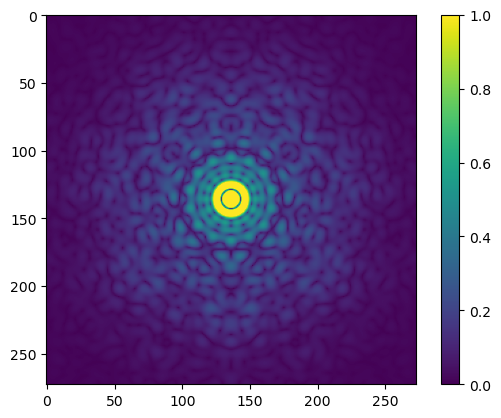

In [5]:
plt.imshow(I**0.3, vmin=0, vmax=1e0, cmap='viridis')
plt.colorbar();

In [10]:
# Plotting division of no offset by big offset in solid angle corrections
sangle_no_offset = np.squeeze(np.load('sangle_no_offset.npy')[:])
sangle_big_offset = np.squeeze(np.load('sangle_big_offset.npy')[:])

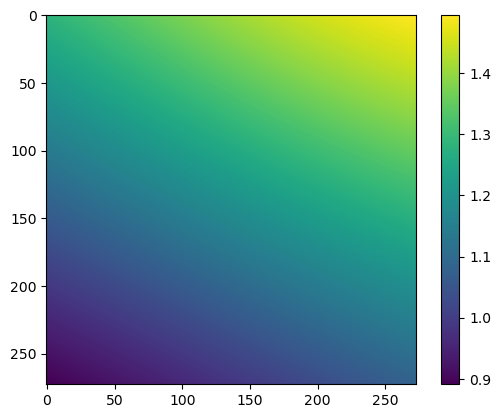

In [14]:
ratio = sangle_no_offset / sangle_big_offset
plt.imshow(ratio, cmap='viridis')
plt.colorbar();

In [12]:
np.unique(ratio)

array([0.89122693, 0.89183492, 0.89244432, ..., 1.49456679, 1.49503781,
       1.49550581])

In [13]:
np.unique(ratio).shape

(73201,)